In [1]:
import pandas as pd
import numpy as np
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [2]:
file_path = "../../data/merged/merged_set_new.parquet"

df = pd.read_parquet(file_path)
df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,rain,snowfall,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation
0,0275e2d8147a31e1ce320c5fb15f9910563cafe1,84957c8960b674346784746bbc1d48cafff4976b162323...,2025-01-01 00:00:00,2025-01-01 00:15:00,758.0,2.93,1.703108e+10,1.703108e+10,8.0,8.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
1,05aa05bf6f3ec476715fad9f706bd137e08e00b7,0cbf5c0f6aca3628d77c7b6fe89715757ed402a70b0f8b...,2025-01-01 00:00:00,2025-01-01 00:15:00,1233.0,13.66,1.703176e+10,1.703106e+10,76.0,6.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
2,17365c83264f028a307ac70308d770fe03bcbcae,c3f8e0b6712bf3ea80e75ddde065b0ed42aa530e8c40cb...,2025-01-01 00:00:00,2025-01-01 00:15:00,985.0,3.22,1.703108e+10,1.703107e+10,8.0,7.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
3,1c629303d7f08492d97e13fabe6a0d1d81e6c9c5,c8f57a1150c210a9e6b3fcfb24c3d6d0a43d1879b4b979...,2025-01-01 00:00:00,2025-01-01 00:15:00,652.0,3.24,1.703122e+10,1.703107e+10,22.0,7.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0
4,1cb48762978a475116ec833c0e4de8ed2ac88e14,88d8896a85cf755c4fb03711d495dc47ca8109196cdef6...,2025-01-01 00:00:00,2025-01-01 00:15:00,803.0,6.09,1.703108e+10,1.703103e+10,8.0,3.0,...,0.0,0.0,0.01,887.8841,0.0,6.927077,4.32,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5339285 entries, 0 to 5339284
Data columns (total 48 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   trip_id                       str    
 1   taxi_id                       str    
 2   trip_start_timestamp          str    
 3   trip_end_timestamp            str    
 4   trip_seconds                  float64
 5   trip_miles                    float64
 6   pickup_census_tract           float64
 7   dropoff_census_tract          float64
 8   pickup_community_area         float64
 9   dropoff_community_area        float64
 10  fare                          float64
 11  tips                          float64
 12  tolls                         float64
 13  extras                        float64
 14  trip_total                    float64
 15  payment_type                  str    
 16  company                       str    
 17  pickup_centroid_latitude      float64
 18  pickup_centroid_longitude     flo

In [4]:
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp'])
df["trip_start_hour"] = pd.to_datetime(df["trip_start_hour"])

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5339285 entries, 0 to 5339284
Data columns (total 48 columns):
 #   Column                        Dtype         
---  ------                        -----         
 0   trip_id                       str           
 1   taxi_id                       str           
 2   trip_start_timestamp          datetime64[us]
 3   trip_end_timestamp            datetime64[us]
 4   trip_seconds                  float64       
 5   trip_miles                    float64       
 6   pickup_census_tract           float64       
 7   dropoff_census_tract          float64       
 8   pickup_community_area         float64       
 9   dropoff_community_area        float64       
 10  fare                          float64       
 11  tips                          float64       
 12  tolls                         float64       
 13  extras                        float64       
 14  trip_total                    float64       
 15  payment_type                  str          

### plot avg trip duration vs temperature:

In [6]:

df["trip_minutes"] = df["trip_seconds"] / 60

df["is_rainy"] = df["rain"] > 0

In [7]:
plot_data = df.groupby(["temperature_2m"])["trip_minutes"].mean().reset_index()


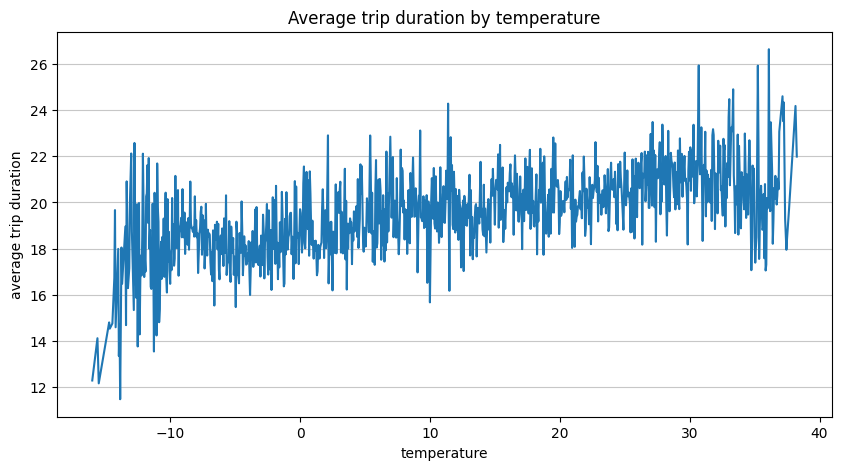

In [8]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=plot_data.sort_values("temperature_2m"),
    x="temperature_2m",
    y="trip_minutes"
)
plt.title('Average trip duration by temperature')
plt.xlabel('temperature')
plt.ylabel('average trip duration')
plt.grid(axis='y', alpha=0.7)
plt.show()

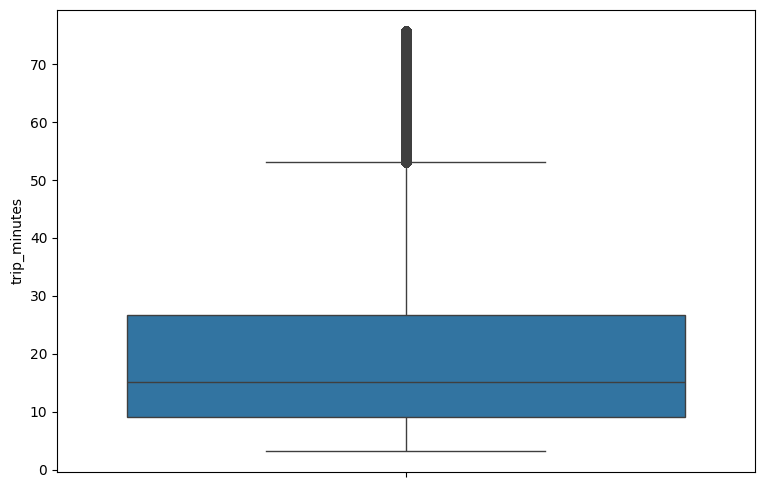

In [9]:
plt.figure(figsize=(9, 6))
sns.boxplot(df["trip_minutes"])
plt.show()

In [10]:
rainy_data = df[df["is_rainy"] == 1]
dry_data = df[df["is_rainy"] == 0]

In [11]:
rainy_data.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,snow_depth,surface_pressure,cloud_cover,wind_speed_10m,wind_speed_100m,is_day,sunshine_duration,direct_radiation,trip_minutes,is_rainy
1200467,05f755a6e67adf4b7ca401b58de66ee5605f1025,55c17b60024566921288582fe7c79716366093e9966024...,2025-04-06 07:00:00,2025-04-06 07:30:00,1720.0,17.56,1.703108e+10,1.703176e+10,8.0,76.0,...,0.0,885.32,100.0,21.711462,29.50518,1.0,0.0,0.0,28.666667,True
1200468,0ce53b5918f14dae3bdb298affdb94aca5eeaab8,d95b99518116b5f943d75828e78c02e668ec6add7d28ba...,2025-04-06 07:00:00,2025-04-06 07:15:00,438.0,2.08,1.703107e+10,1.703132e+10,7.0,32.0,...,0.0,885.32,100.0,21.711462,29.50518,1.0,0.0,0.0,7.300000,True
1200469,1aed82bf7dc6261e3f8f73a4c8c950530c8da4f6,cdb5dabbf347707495209b5004193279f8b57994b7c456...,2025-04-06 07:00:00,2025-04-06 07:45:00,2755.0,2.50,1.703106e+10,1.703103e+10,6.0,3.0,...,0.0,885.32,100.0,21.711462,29.50518,1.0,0.0,0.0,45.916667,True
1200470,1c8a4f9117d99611161f29480ae841002411e549,41ba5cfc7d59a833c94ed0b59fcc8a5f3aa5ca1b291325...,2025-04-06 07:00:00,2025-04-06 07:30:00,1764.0,15.63,1.703107e+10,1.703176e+10,7.0,76.0,...,0.0,885.32,100.0,21.711462,29.50518,1.0,0.0,0.0,29.400000,True
1200471,2418a6b02bf46408bcbb965742ec088eb3b34050,a79d72d3d49bed13558577cc0608caf7e8da5b9cee67b6...,2025-04-06 07:00:00,2025-04-06 07:15:00,1297.0,10.62,1.703134e+10,1.703149e+10,34.0,49.0,...,0.0,885.32,100.0,21.711462,29.50518,1.0,0.0,0.0,21.616667,True


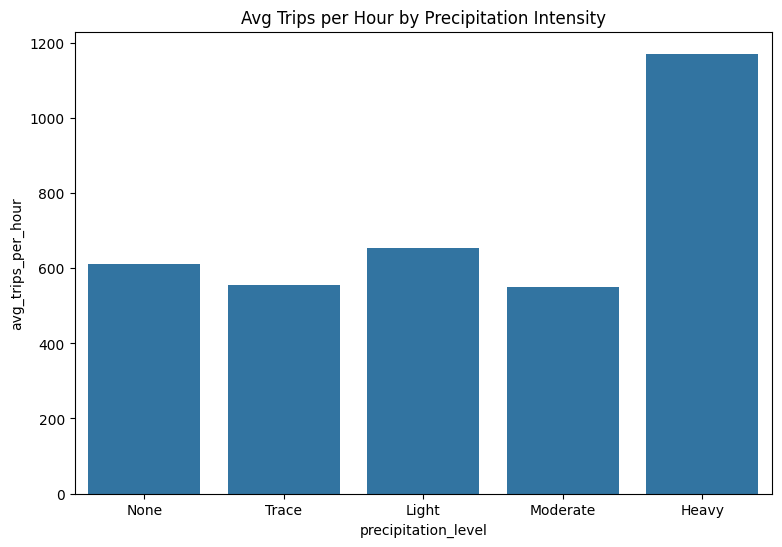

In [12]:
df['precipitation_level'] = pd.cut(
    df['precipitation'],
    bins=[-0.001, 0, 0.5, 2, 5, 100],
    labels=['None', 'Trace', 'Light', 'Moderate', 'Heavy']
)

precipitation_rate = (
    df.groupby(['precipitation_level', 'trip_start_hour'])
      .size()
      .groupby('precipitation_level')
      .mean()
      .reset_index(name='avg_trips_per_hour')
)

plt.figure(figsize=(9, 6))
sns.barplot(data = precipitation_rate, x = "precipitation_level", y="avg_trips_per_hour")
plt.title('Avg Trips per Hour by Precipitation Intensity')
plt.xticks(rotation=0)
plt.show()

Text(0.5, 0, 'Month')

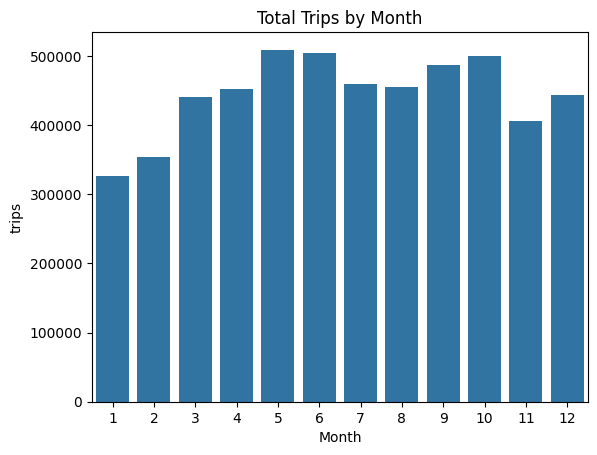

In [13]:
monthly = df.groupby('start_month').size().reset_index(name='trips')
sns.barplot(data=monthly, x='start_month', y='trips')
plt.title('Total Trips by Month')
plt.xlabel('Month')

average demand per hour, dry vs rainy:

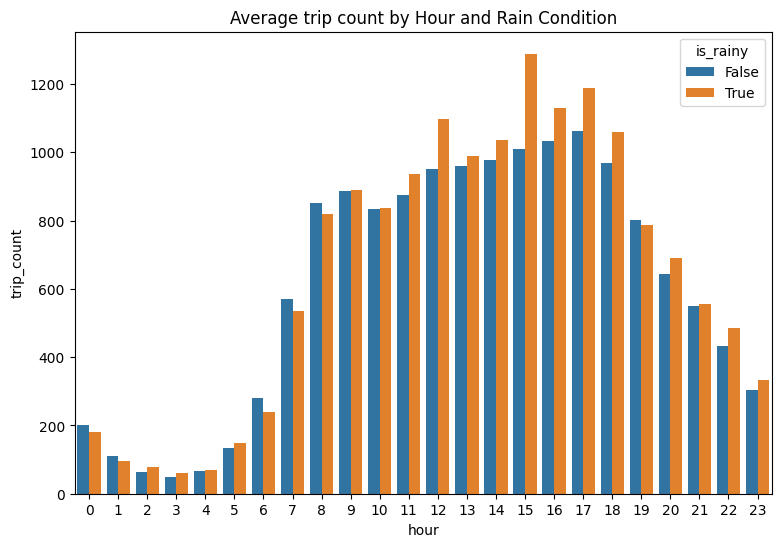

In [14]:
hourly_demand = (
    df.groupby(["trip_start_hour", "is_rainy"])
      .size()
      .reset_index(name="trip_count")
)

hourly_demand["hour"] = hourly_demand["trip_start_hour"].dt.hour

avg_demand = (
    hourly_demand.groupby(["hour", "is_rainy"])["trip_count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_demand, x = "hour", y="trip_count", hue = "is_rainy")
plt.title("Average trip count by Hour and Rain Condition")
plt.show()

average trip duration per hour, dry vs rainy:

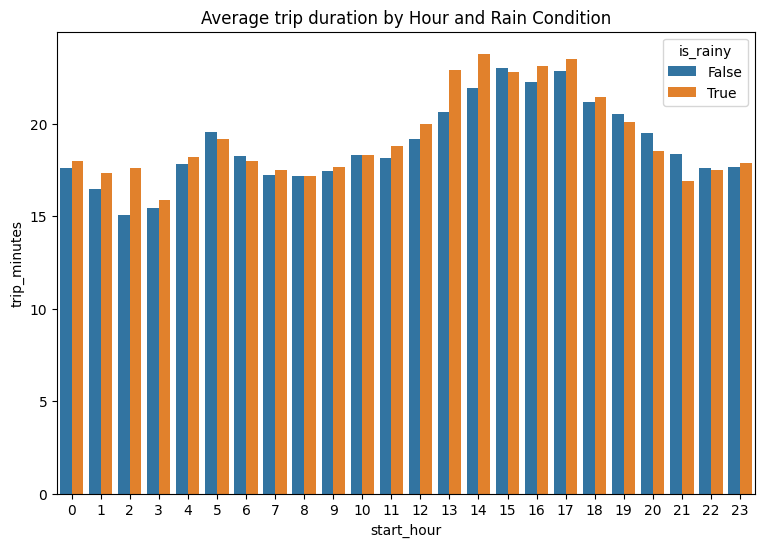

In [15]:
avg_duration = (
    df.groupby(["start_hour", "is_rainy"])["trip_minutes"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_duration, x = "start_hour", y="trip_minutes", hue = "is_rainy")
plt.title("Average trip duration by Hour and Rain Condition")
plt.show()

average trip distance per hour, dry vs rainy:

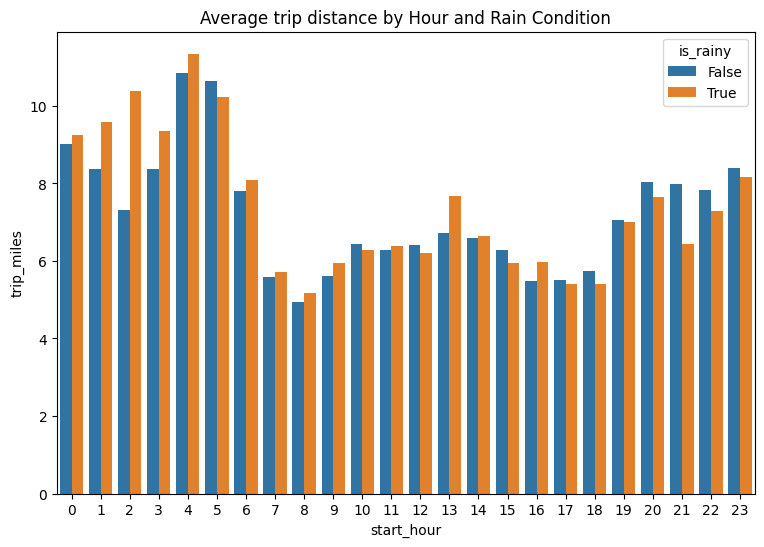

In [16]:
avg_distance = (
    df.groupby(["start_hour", "is_rainy"])["trip_miles"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_distance, x = "start_hour", y="trip_miles", hue = "is_rainy")
plt.title("Average trip distance by Hour and Rain Condition")
plt.show()

average fare per mile per hour, dry vs rainy:

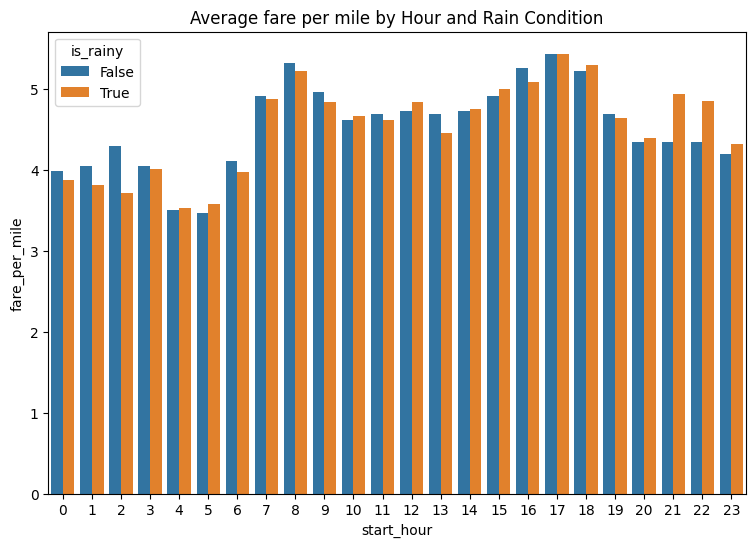

In [17]:
df['fare_per_mile'] = df['fare'] / df['trip_miles'].replace(0, np.nan)

avg_fare_per_mile = (
    df.groupby(["start_hour", "is_rainy"])["fare_per_mile"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_fare_per_mile, x = "start_hour", y="fare_per_mile", hue = "is_rainy")
plt.title("Average fare per mile by Hour and Rain Condition")
plt.show()

average tip rate per hour, dry vs rainy:

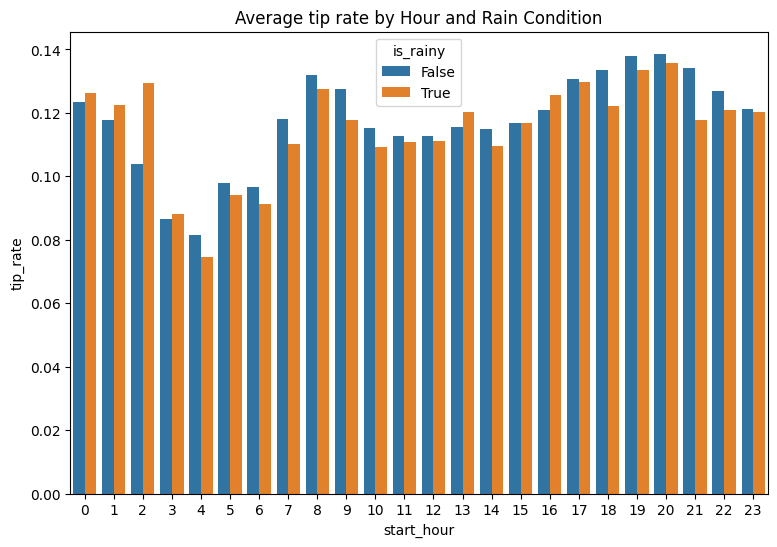

In [18]:
df['tip_rate'] = df['tips'] / df['fare']

avg_tip_rate = (
    df.groupby(["start_hour", "is_rainy"])["tip_rate"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_tip_rate, x = "start_hour", y="tip_rate", hue = "is_rainy")
plt.title("Average tip rate by Hour and Rain Condition")
plt.show()

average idle time per hour, dry vs rainy:

Finding the end time of each taxi's previous trip...
Calculating idle time in minutes...
 Actively cleaning and fixing data anomalies...
Dropping temporary columns to preserve RAM...
Dropped 3034 first trips (no history)
Clamped 51209 overlapping trips to 0
Removed 1316395 off-duty gaps (>120 min)


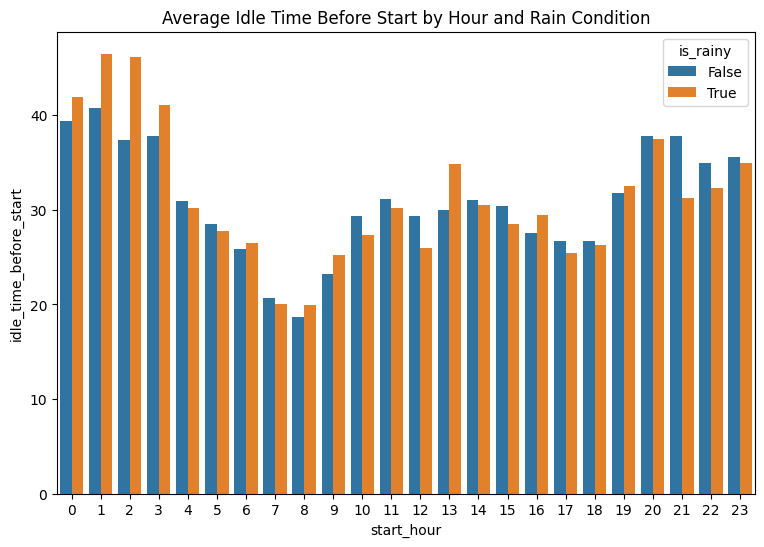

In [19]:
df_idle = df[['taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'is_rainy', 'start_hour']].copy()
df_idle = df_idle.sort_values(['taxi_id', 'trip_start_timestamp'])


print("Finding the end time of each taxi's previous trip...")
df_idle['prev_trip_end'] = df_idle.groupby('taxi_id')['trip_end_timestamp'].shift(1)

print("Calculating idle time in minutes...")
time_diff = df_idle['trip_start_timestamp'] - df_idle['prev_trip_end']
df_idle['idle_time_before_start'] = time_diff.dt.total_seconds() / 60.0

print(" Actively cleaning and fixing data anomalies...")

# Explicitly count and drop the first trip of every taxi since history is unknown
n_before_anomaly_a = len(df_idle)
df_idle = df_idle.dropna(subset=['idle_time_before_start']).reset_index(drop=True)
dropped_first_trips = n_before_anomaly_a - len(df_idle)

# Overlapping trips: force negative idle times to 0 minutes
overlap_count = (df_idle['idle_time_before_start'] < 0).sum()
df_idle.loc[df_idle['idle_time_before_start'] < 0, 'idle_time_before_start'] = 0

# Off-duty shifts: If a gap is > 2 hours, it's a break. Set to NaN so it doesn't pollute averages.
break_count = (df_idle['idle_time_before_start'] > 120).sum()
df_idle.loc[df_idle['idle_time_before_start'] > 120, 'idle_time_before_start'] = np.nan

print("Dropping temporary columns to preserve RAM...")
df_idle = df_idle.drop(columns=['prev_trip_end'])

print(f"Dropped {dropped_first_trips} first trips (no history)")
print(f"Clamped {overlap_count} overlapping trips to 0")
print(f"Removed {break_count} off-duty gaps (>120 min)")

avg_idle_time = (
    df_idle.groupby(["start_hour", "is_rainy"])["idle_time_before_start"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(9, 6))
sns.barplot(data=avg_idle_time, x = "start_hour", y="idle_time_before_start", hue = "is_rainy")
plt.title("Average Idle Time Before Start by Hour and Rain Condition")
plt.show()

Text(0.5, 1.0, 'Average Hourly Demand: Weekday vs Weekend')

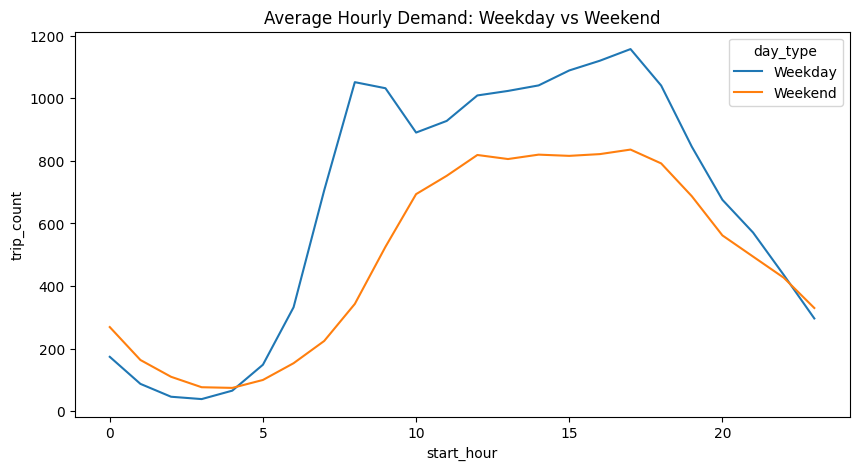

In [20]:
df["day_of_week"] = df["trip_start_timestamp"].dt.dayofweek
df["is_weekend"] = df["day_of_week"] >= 5

avg_demand_week = (
    df.groupby(["trip_start_hour", "is_weekend"])
      .size()
      .reset_index(name="trip_count")
)
avg_demand_week["start_hour"] = avg_demand_week["trip_start_hour"].dt.hour

avg_demand_week = avg_demand_week.groupby(["start_hour", "is_weekend"])["trip_count"].mean().reset_index()

avg_demand_week["day_type"] = avg_demand_week["is_weekend"].map({True: "Weekend", False: "Weekday"})

plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_demand_week, x="start_hour", y="trip_count", hue="day_type")
plt.title("Average Hourly Demand: Weekday vs Weekend")